### Miguel Baños Baladrón
### Miguel Pérez Francos
### Rodrigo Touceda Tapias


# Proyecto de investigación: Reconocimiento de Actividades Humanas (HAR) con Sensores Inerciales

# Importaciones

In [23]:
# Incluimos scripts necesarios
include("setup.jl")
include("helpers.jl")
include("wrappers.jl")

# Usamos JLD2 para recuperar el estado exacto del preprocesamiento
if isfile("datos_procesados.jld2")
    JLD2.@load "datos_procesados.jld2" df_trainval df_test X_trainval y_trainval folds_trainval
    println("Datos cargados correctamente.")
else
    error("No se encontró 'datos_procesados.jld2'. Ejecuta primero Preprocess.ipynb.")
end

"""
Aunque los datos ya los imputamos en el preprocesado (no tienen nulos), Julia suele mantener el tipo de columna como "Union{Missing, Float64}". 
Esto es problemático porque muchas librerías de (LIBSVM, XGBoost) fallan si no reciben arrays numéricos estrictos. La función `disallowmissing` fuerza 
la conversión a tipos puros (Float64/Int)
"""

X_trainval = disallowmissing(X_trainval)

y_test = df_test.Activity
X_test_dirty = DataFrames.select(df_test, Not([:subject, :Activity]))

# Aplicamos la corrección de tipos para asegurar compatibilidad
X_test = disallowmissing(X_test_dirty)

# Reset del esquema del dataframe de test original (para visualización/análisis posterior)
allowmissing!(df_test)
df_test = disallowmissing(df_test)

println("Tipos corregidos: X_trainval y X_test ya no admiten missings.")

Entorno y modelos cargados correctamente
Datos cargados correctamente.
Tipos corregidos: X_trainval y X_test ya no admiten missings.


# Función para ejecutar modelos
Esta función tiene como objetivo sistematizar la evaluación de combinaciones entre técnias de selección de características, reducción de dimensionalidad y clasificadores:
- Para que cada técnica aparezca al menos una vez, calculamos el número máximo de iteraciones (usando la lista de los modelos, la más larga) y se asignan filtros y reducciones de forma cíclica.
- Es reproducible, ya que convierte los diccionarios en listas ordenadas alfabéticamente.
- Añadimos una lógica de checkpoint, para que en caso de que la ejecución se detenga antes de terminar, la reanude desde el error, en vez de volver a empezar. Guardamos las métricas en un CSV.
- Extraemos accuracy, f1_score, balanced_accuracy media y por cada fold.

In [2]:
function run_models(dic_filtros, dic_reducciones, dic_modelos, output_file; 
                    X=X_trainval, y=y_trainval, folds=folds_trainval)
    
    # Ordenamos los componentes para garantizar ejecución determinista
    list_filtros     = sort(collect(dic_filtros), by=x->x[1])
    list_reducciones = sort(collect(dic_reducciones), by=x->x[1])
    list_modelos     = sort(collect(dic_modelos), by=x->x[1])

    n_filtros = length(list_filtros)
    n_reducciones = length(list_reducciones)
    n_modelos = length(list_modelos)

    # El número de experimentos se define por la lista más larga
    max_iter = max(n_filtros, n_reducciones, n_modelos)
    
    # Lógica de reanudación (para reanudar ejecuciones, no volver a empezarlas)
    if isfile(output_file)
        results_df = CSV.read(output_file, DataFrame)
        combinaciones_hechas = Set([
            (string(r.Filter), string(r.Reduction), string(r.Model)) 
            for r in eachrow(results_df)
        ])
    else
        results_df = DataFrame(
            Filter = String[], Reduction = String[], Model = String[],
            Accuracy_Mean = Float64[], 
            F1_Score = Float64[], 
            B_Accuracy_mean = Float64[],
            B_accuracy_list = String[]
        )
        combinaciones_hechas = Set{Tuple{String, String, String}}()
    end
    
    measures = [accuracy, multiclass_f1score, balanced_accuracy]

    println("Iniciando ejecución secuencial: $max_iter experimentos.")

    for i in 1:max_iter
        # Selección de componentes
        pair_filt = list_filtros[(i - 1) % n_filtros + 1]
        pair_red  = list_reducciones[(i - 1) % n_reducciones + 1]
        pair_mod  = list_modelos[(i - 1) % n_modelos + 1]

        filt_name, filt_model = pair_filt
        red_name, red_model   = pair_red
        mod_name, mod_model   = pair_mod

        if (filt_name, red_name, mod_name) in combinaciones_hechas
            continue 
        end

        println("\nEvaluando ($i/$max_iter): $filt_name + $red_name + $mod_name")
        
        pipe = PersonalizedPipeline(
            scaler    = MyMinMaxScaler(), 
            filter    = filt_model,       
            reduction = red_model,       
            clf       = mod_model        
        )
        
        try
            mach = machine(pipe, X, y) 
            
            # Evaluación con validación cruzada
            evaluation = evaluate!(
                mach, 
                resampling = folds, 
                measures = measures, 
                verbosity = 0,
                acceleration = CPUThreads() 
            )
            
            acc_mean    = evaluation.measurement[1]
            f1_mean     = evaluation.measurement[2]
            b_acc_mean  = evaluation.measurement[3]
            b_acc_folds = evaluation.per_fold[3]
            b_acc_str = join(round.(b_acc_folds, digits=5), ";")

            println("Acc: $(round(acc_mean, digits=4)) | F1: $(round(f1_mean, digits=4)) | B_acc: $(round(b_acc_mean, digits=4))")
            
            # Escritura a disco
            push!(results_df, (filt_name, red_name, mod_name, acc_mean, f1_mean, b_acc_mean, b_acc_str), promote=true)
            CSV.write(output_file, results_df)
            
        catch e
            println("ERROR en $filt_name + $red_name + $mod_name: $e")
            push!(results_df, (filt_name, red_name, mod_name, NaN, NaN, NaN, "ERROR"))
            CSV.write(output_file, results_df)
        end
        
        GC.gc()
    end
    
    println("Experimento finalizado.")
    return results_df
end;

# Definición de los diccionarios para los modelos básicos y selección de atributos

In [3]:
# Diccionarios de los filtrados
dic_filtros = Dict(
    "Sin_Filtrado" => nothing,
    "ANOVA" => MyANOVAFilter(n_features=N_FEATURES),
    "Pearson" => MyPearsonFilter(n_features=N_FEATURES),
    "Spearman" => MySpearmanFilter(n_features=N_FEATURES),
    "Kendall" => MyKendallFilter(n_features=N_FEATURES),
    "MI" => MyMIFilter(n_features=N_FEATURES),
    "RFE" => MyRFEFilter(n_features=N_FEATURES)
)

# Diccionarios de las reducciones de dimensionalidad
dic_reducciones = Dict(
    "Sin reducción" => IdentityTransformer(),
    "PCA" => PCA(variance_ratio=0.95), # Conservar el 95% de la varianza
    "ICA" => ICA(outdim=2, maxiter=10000,tol=0.5), # Tolerancia alta para evitar error
    "LDA" => LDA(method=:whiten, outdim=5) # En LDA, la dimensión es n_classes - 1
)

# Diccionarios de modelos
dic_modelos = Dict(
    # MLP
    "NeuralNetwork_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
    "NeuralNetwork_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
    "NeuralNetwork_100_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))),
    
    # KNN
    "KNN_1" => KNNClassifier(K=1),
    "KNN_10" => KNNClassifier(K=10),
    "KNN_20" => KNNClassifier(K=20),

    # SVM
    "SVM_0.1" => ProbabilisticSVC(cost=0.1),
    "SVM_0.5" => ProbabilisticSVC(cost=0.5),
    "SVM_1.0" => ProbabilisticSVC(cost=1.0)
);

In [4]:
# Ejecutar y guardar
df_resultados_basicos = run_models(
    dic_filtros, 
    dic_reducciones, 
    dic_modelos, 
    "resultados_modelos_basicos.csv"
)

Iniciando ejecución secuencial: 9 experimentos.
Experimento finalizado.


Row,Filter,Reduction,Model,Accuracy_Mean,F1_Score,B_Accuracy_mean,B_accuracy_list
,String15,String15,String31,Float64,Float64,Float64,String
1,ANOVA,ICA,KNN_1,0.591744,0.590583,0.590066,0.62677;0.55199;0.61759;0.57407;0.5792
2,Kendall,LDA,KNN_10,0.957523,0.957549,0.957705,0.96633;0.94923;0.95082;0.94778;0.97424
3,MI,PCA,KNN_20,0.894079,0.893302,0.893082,0.89989;0.87871;0.89793;0.91762;0.87073
4,Pearson,Sin reducción,NeuralNetwork_100,0.893753,0.890863,0.892993,0.9291;0.84141;0.88771;0.86468;0.94273
5,RFE,ICA,NeuralNetwork_100_50,0.586312,0.550403,0.584556,0.58401;0.56956;0.5786;0.53971;0.65389
6,Sin_Filtrado,LDA,NeuralNetwork_50,0.889517,0.885942,0.893031,0.89364;0.91274;0.90341;0.91095;0.84206
7,Spearman,PCA,SVM_0.1,0.910483,0.909962,0.910647,0.9292;0.89265;0.92234;0.9105;0.89776
8,ANOVA,Sin reducción,SVM_0.5,0.933732,0.933374,0.933782,0.9595;0.91366;0.93447;0.92812;0.93167
9,Kendall,ICA,SVM_1.0,0.670831,0.66181,0.669607,0.67827;0.67086;0.69487;0.66097;0.64239


# Definición de los diccionarios de los modelos de ensemble (Primer Experimento)
- En el caso de AdaBoost, usamos AdaBoostStumpClassifier que a diferencia de usar SVM como base, usa Decission Stumps (Decission Trees de profundidad 1). Como son aprendices débiles, ejecutamos varios modelos para encontrar un número de iteraciones óptimo. Hasta las 300 iteraciones obtuvimos mejoría, pero en las 400, empeoraron las métricas, mostrando overfitting.

In [5]:
# No se especifica usar ningún filtrado para ensembles, debemos decirle a nuestra función que no hay
dic_filtros_ensemble = Dict(
    "Sin_Filtrado" => nothing
)

# Usamos PCA con el 95% de la varianza o ninguno
dic_reducciones_ensemble = Dict(
    "Sin_Reduccion" => IdentityTransformer(), 
    "PCA_95"        => PCA(variance_ratio=0.95)
)

# Definición del knn base para Bagging
knn_base = KNNClassifier(K=5)

# Diccionario de los modelos de ensemble
dic_modelos_ensemble = Dict(
    # BaggingClassifier
    "Bagging_KNN_10" => EnsembleModel(model = knn_base, n = 10),
    "Bagging_KNN_50" => EnsembleModel(model = knn_base, n = 50),

    # AdaBoost
    "AdaBoost" => AdaBoostStumpClassifier(n_iter = 100),
    "AdaBoost200" => AdaBoostStumpClassifier(n_iter = 200),
    "AdaBoost300" => AdaBoostStumpClassifier(n_iter = 300),
    "AdaBoost400" => AdaBoostStumpClassifier(n_iter = 400),

    # EvoTree
    "EvoTree_50" => EvoTreeClassifier(nrounds = 50, eta = 0.2),
    "EvoTree_100" => EvoTreeClassifier(nrounds = 100, eta = 0.2)
);

In [6]:
df_resultados_ensembles = run_models(
    dic_filtros_ensemble, 
    dic_reducciones_ensemble, 
    dic_modelos_ensemble, 
    "resultados_modelos_ensemble.csv"
)

Iniciando ejecución secuencial: 8 experimentos.
Experimento finalizado.


Row,Filter,Reduction,Model,Accuracy_Mean,F1_Score,B_Accuracy_mean,B_accuracy_list
,String15,String15,String15,Float64,Float64,Float64,String
1,Sin_Filtrado,PCA_95,AdaBoost,0.678979,0.660709,0.680322,0.69891;0.66974;0.65539;0.73831;0.6353
2,Sin_Filtrado,Sin_Reduccion,AdaBoost200,0.686475,0.622646,0.683848,0.69959;0.74708;0.74516;0.56501;0.6598
3,Sin_Filtrado,PCA_95,AdaBoost300,0.717545,0.708043,0.718855,0.69365;0.73162;0.72019;0.77213;0.67699
4,Sin_Filtrado,Sin_Reduccion,AdaBoost400,0.693862,0.645679,0.697611,0.68637;0.75629;0.7776;0.57012;0.69961
5,Sin_Filtrado,PCA_95,Bagging_KNN_10,0.887452,0.885775,0.885976,0.88429;0.88673;0.88089;0.91101;0.86613
6,Sin_Filtrado,Sin_Reduccion,Bagging_KNN_50,0.895817,0.894281,0.89416,0.89915;0.88716;0.88855;0.92028;0.87459
7,Sin_Filtrado,PCA_95,EvoTree_100,0.881477,0.877813,0.878653,0.90069;0.87467;0.89897;0.88948;0.82665
8,Sin_Filtrado,Sin_Reduccion,EvoTree_50,0.918197,0.916742,0.917156,0.94231;0.88292;0.91685;0.91872;0.92454


# Evaluación final sobre el conjunto de test

- Para realizar la evaluación final y la construcción de los modelos compuestos (Stacking, Voting), unificamos todos los componentes anteriores.
- Recuperamos la mejor configuración específica (Filtro + Reducción + Modelo) obtenida durante la validación cruzada para cada una de las familias de algoritmos para no instanciarlos manualmente.

In [7]:
# Unificamos diccionarios
all_filtros     = merge(dic_filtros, dic_filtros_ensemble)
all_reducciones = merge(dic_reducciones, dic_reducciones_ensemble)
all_modelos     = merge(dic_modelos, dic_modelos_ensemble);

In [8]:
best_knn = get_better("KNN", "resultados_modelos_basicos.csv") # Mejor KNN
best_svm = get_better("SVM", "resultados_modelos_basicos.csv") # Mejor SVM
best_mlp = get_better("NeuralNetwork", "resultados_modelos_basicos.csv") # Mejor MLP 
best_bagging = get_better("Bagging", "resultados_modelos_ensemble.csv") # Mejor Bagging 
best_adaboost = get_better("AdaBoost", "resultados_modelos_ensemble.csv") # Mejor AdaBoost
best_evotree = get_better("EvoTree", "resultados_modelos_ensemble.csv"); # Mejor EvoTree

Mejor KNN encontrado:
Config: Kendall + LDA + KNN_10
-> B_Accuracy_mean: 0.9577

Mejor SVM encontrado:
Config: ANOVA + Sin reducción + SVM_0.5
-> B_Accuracy_mean: 0.9338

Mejor NeuralNetwork encontrado:
Config: Sin_Filtrado + LDA + NeuralNetwork_50
-> B_Accuracy_mean: 0.893

Mejor Bagging encontrado:
Config: Sin_Filtrado + Sin_Reduccion + Bagging_KNN_50
-> B_Accuracy_mean: 0.8942

Mejor AdaBoost encontrado:
Config: Sin_Filtrado + PCA_95 + AdaBoost300
-> B_Accuracy_mean: 0.7189

Mejor EvoTree encontrado:
Config: Sin_Filtrado + Sin_Reduccion + EvoTree_50
-> B_Accuracy_mean: 0.9172



In [9]:
# Agrupamos los mejores modelos encontrados en un diccionario
mejores_modelos = Dict(
    "SVM (Best)" => best_svm,
    "KNN (Best)" => best_knn,
    "MLP (Best)" => best_mlp,
    "Bagging (Best)" => best_bagging,
    "AdaBoost (Best)" => best_adaboost,
    "EvoTree (Best)" => best_evotree
)

# Archivos de salida
output_file_test = "resultados_finales_test.csv"
output_matrices_test = "matrices_conf_test.jld2"

# Cargar CSV
if isfile(output_file_test)
    println("=== Archivo CSV detectado. Cargando resultados previos ===")
    resultados_test = CSV.read(output_file_test, DataFrame)
    resultados_test.Modelo = string.(resultados_test.Modelo)
    modelos_ya_calculados = Set(resultados_test.Modelo)
else
    println("=== No se encontró CSV previo. Creando nueva tabla ===")
    resultados_test = DataFrame(Modelo=String[], Accuracy=Float64[], F1_Score=Float64[], B_Accuracy=Float64[])
    modelos_ya_calculados = Set{String}()
end

# Cargar Matrices de Confusión
if isfile(output_matrices_test)
    JLD2.@load output_matrices_test dic_matrices_test
    println("=== Matrices de confusión previas cargadas. ===")
else
    dic_matrices_test = Dict()
end

println("\n=== Iniciando Evaluación Final en TEST ===")

for (nombre, pipeline) in mejores_modelos
    
    # Checkpoint
    if (nombre in modelos_ya_calculados) && (haskey(dic_matrices_test, nombre))
        println("-> Saltando: $nombre (Ya existe en CSV y Diccionario)")
        continue 
    end

    println("Procesando: $nombre ...")

    # Creamos la machine
    mach = machine(pipeline, X_trainval, y_trainval)
    
    # Entrenamos
    fit!(mach, verbosity=0)
    
    # Evaluamos con test
    y_pred = predict_mode(mach, X_test)
    
    # Calculamos métricas
    acc   = accuracy(y_pred, y_test)
    f1    = multiclass_f1score(y_pred, y_test)
    b_acc = balanced_accuracy(y_pred, y_test)
    
    # Guardamos métricas en DataFrame y CSV
    if !(nombre in modelos_ya_calculados)
        push!(resultados_test, (nombre, acc, f1, b_acc))
        CSV.write(output_file_test, resultados_test)
    end
    
    # Guardamos Matriz en Diccionario y JLD2
    cm = confusion_matrix(y_pred, y_test)
    dic_matrices_test[nombre] = cm
    @save output_matrices_test dic_matrices_test # Guardado incremental
    
end

println("\nProceso completado.")
println("Métricas guardadas en: $output_file_test")
println("Matrices guardadas en: $output_matrices_test")

# Mostrar tabla resumen
println("\nResultados Finales en Test:")
resultados_test

=== Archivo CSV detectado. Cargando resultados previos ===
=== Matrices de confusión previas cargadas. ===

=== Iniciando Evaluación Final en TEST ===
-> Saltando: SVM (Best) (Ya existe en CSV y Diccionario)
-> Saltando: AdaBoost (Best) (Ya existe en CSV y Diccionario)
-> Saltando: EvoTree (Best) (Ya existe en CSV y Diccionario)
-> Saltando: KNN (Best) (Ya existe en CSV y Diccionario)
-> Saltando: MLP (Best) (Ya existe en CSV y Diccionario)
-> Saltando: Bagging (Best) (Ya existe en CSV y Diccionario)

Proceso completado.
Métricas guardadas en: resultados_finales_test.csv
Matrices guardadas en: matrices_conf_test.jld2

Resultados Finales en Test:


Row,Modelo,Accuracy,F1_Score,B_Accuracy
,String15,Float64,Float64,Float64
1,SVM (Best),0.902194,0.878588,0.885348
2,AdaBoost (Best),0.738574,0.706983,0.720158
3,EvoTree (Best),0.865631,0.843422,0.850692
4,KNN (Best),0.956124,0.950527,0.949871
5,MLP (Best),0.936929,0.931995,0.930312
6,Bagging (Best),0.875686,0.84901,0.859283


## Matrices de Confusión tras evaluar en test

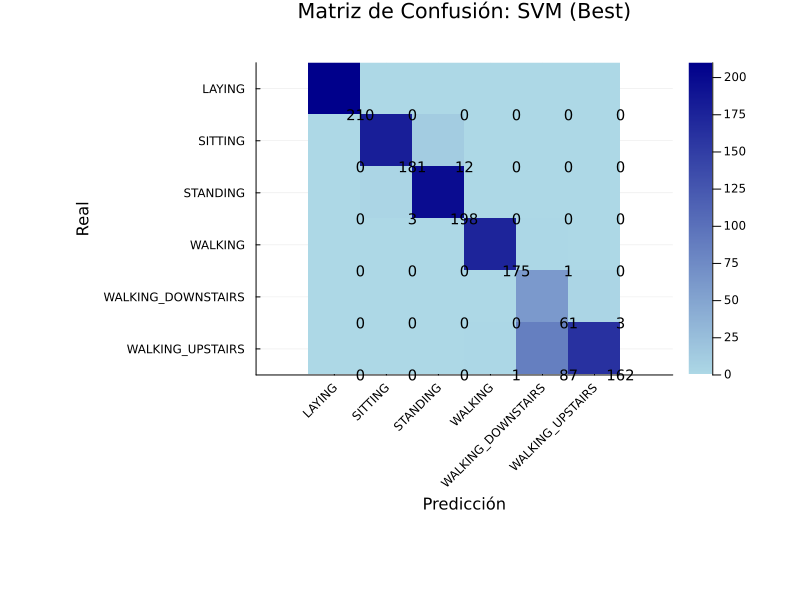

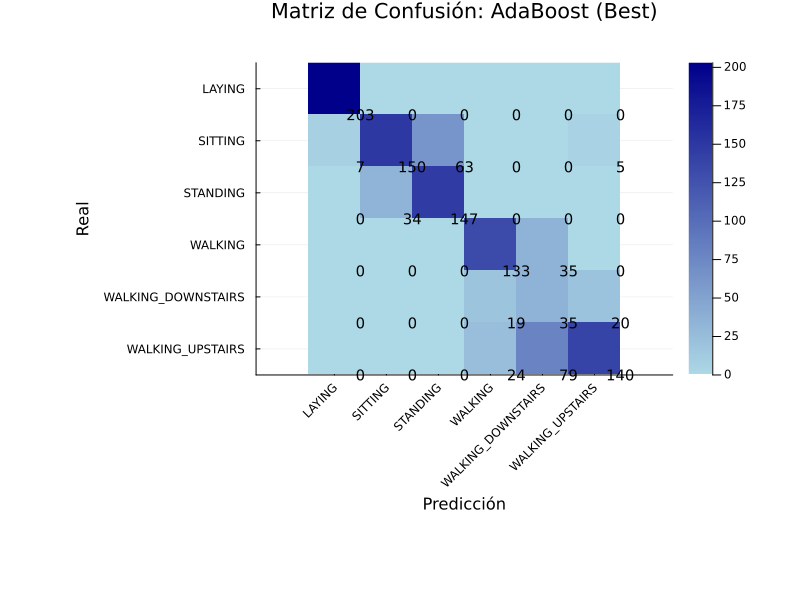

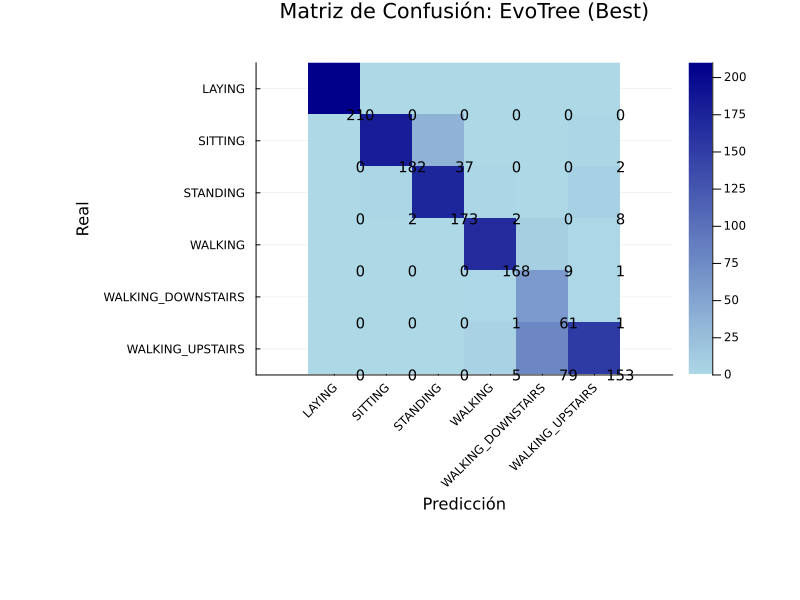

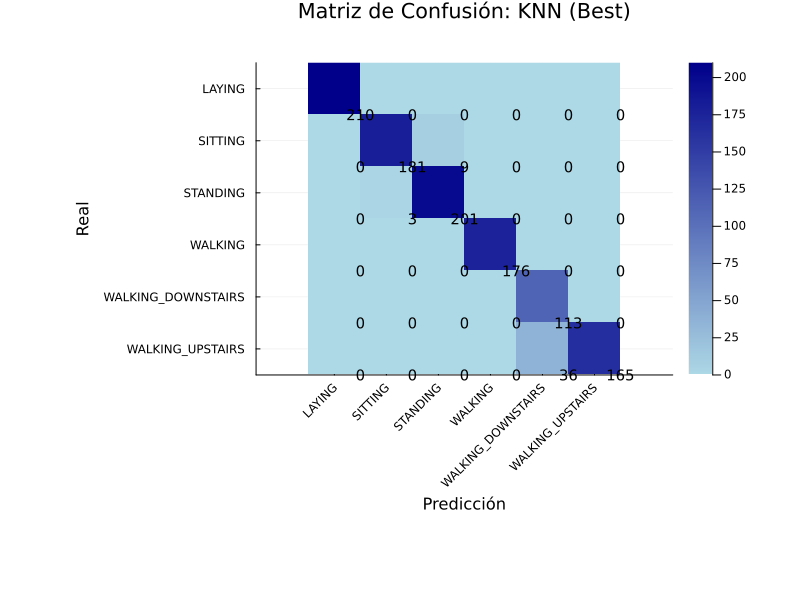

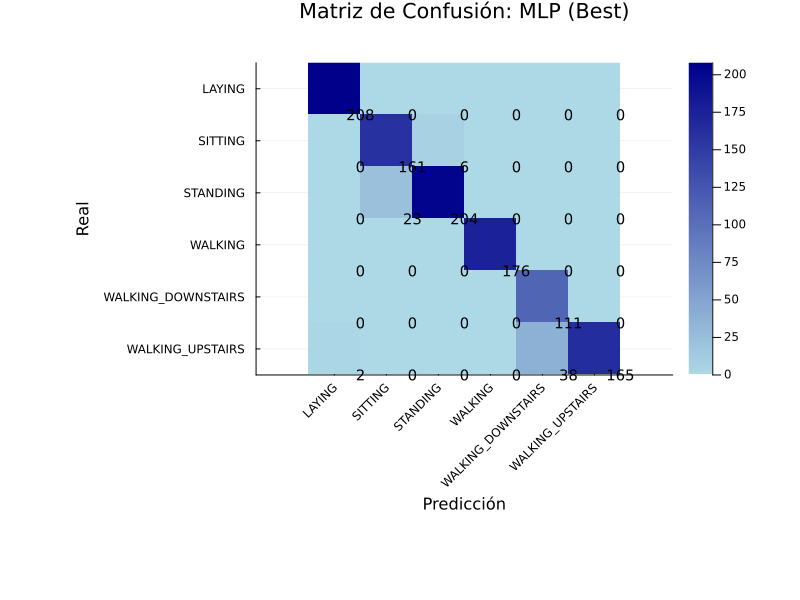

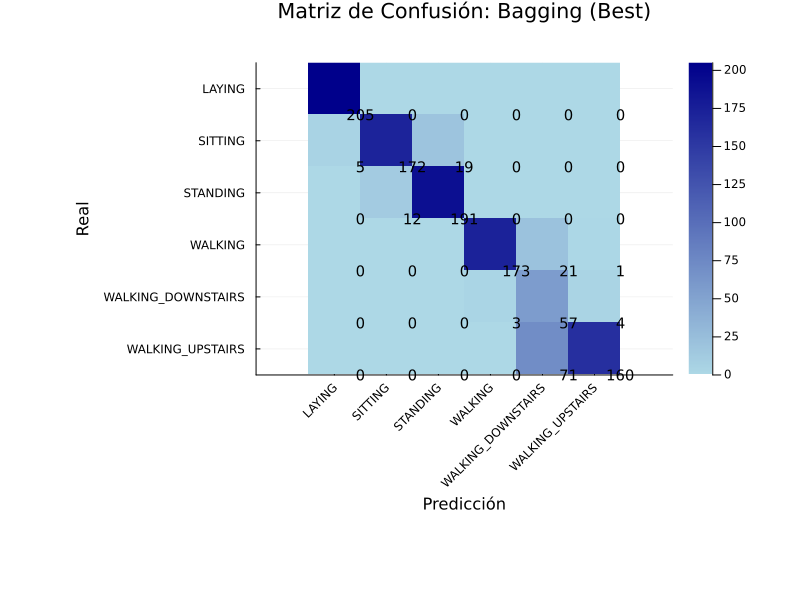

In [10]:
show_cm(dic_matrices_test)

# Modelos de ensemble (Segundo Experimento) usando entrenamiento y validación para entrenar y test para evaluar

In [11]:
modelos_finales = Dict(
    # Random Forest
    "RandomForest" => RandomForestClassifier(n_trees=500, max_depth=10, rng= Random.MersenneTwister(SEED)),
    
    # Hard Voting
    "HardVoting_Wrapper" => HardVotingClassifier(
        base_model = best_svm, 
        n_partitions = 3, 
        rng = 104
    ),
    
    # Stacking
    "Stacking" => Stack(
        metalearner = NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
        resampling  = CV(nfolds=3),
        model1      = best_svm,
        model2      = best_knn,
        model3      = best_mlp
    ),
    
    # XGBoost
    "XGBoost" => XGBoostClassifier(objective = "multi:softprob", seed=SEED),
    
    # LightGBM
    "LightGBM" => LGBMClassifier(seed=SEED)
);

output_file = "resultados_modelos_ensemble_finales.csv"
output_matrices = "matrices_ensemble_finales.jld2"

dic_matrices_ensembles_finales = Dict()

# Carga de resultados previos del CSV si existen
if isfile(output_file)
    println("Archivo CSV detectado cargando resultados previos")
    existing_results = CSV.read(output_file, DataFrame)
    existing_results.Model = string.(existing_results.Model)
    models_calculated = Set(existing_results.Model)
else
    println("No se encontro CSV previo creando nueva tabla")
    CSV.write(output_file, DataFrame(Model=String[], Accuracy=Float64[], F1=Float64[], B_Accuracy=Float64[]))
    models_calculated = Set{String}()
end

# Carga de matrices previas del JLD2 si existen
if isfile(output_matrices)
    JLD2.@load output_matrices dic_matrices_ensembles_finales
    println("Matrices de confusion previas cargadas")
else
    dic_matrices_ensembles_finales = Dict()
end

println("\nIniciando ejecucion de los 5 Ensembles Finales")

for (nombre, modelo) in modelos_finales
    
    # Checkpoint
    if (nombre in models_calculated) && (haskey(dic_matrices_ensembles_finales, nombre))
        println("Saltando $nombre ya existe en CSV y Diccionario")
        continue
    end

    println("\nProcesando $nombre")
    
    try
        # Entrenamos
        mach = machine(modelo, X_trainval, y_trainval)
        fit!(mach, verbosity=0)
        
        # Predecimos
        y_pred = nothing
        if nombre == "HardVoting_Wrapper"
            println("Usando predict modo determinista")
            y_pred = MLJ.predict(mach, X_test)
        else
            println("Usando predict_mode modo probabilistico")
            y_pred = predict_mode(mach, X_test)
        end
        
        # Metricas
        acc   = accuracy(y_pred, y_test)
        f1    = multiclass_f1score(y_pred, y_test)
        b_acc = balanced_accuracy(y_pred, y_test)
        
        # Guardamos metricas en CSV
        CSV.write(output_file, DataFrame(Model=[nombre], Accuracy=[acc], F1=[f1], B_Accuracy=[b_acc]), append=true)
        
        # Guardamos matriz en diccionario y persistimos en JLD2
        dic_matrices_ensembles_finales[nombre] = confusion_matrix(y_pred, y_test)
        @save output_matrices dic_matrices_ensembles_finales
        
        println("$nombre completado B_Acc $(round(b_acc, digits=4))")
        
    catch e
        println("Error en $nombre $e")
    end
    
    # Liberar memoria
    GC.gc() 
end

println("\nResultados guardados en $output_file")

Archivo CSV detectado cargando resultados previos
Matrices de confusion previas cargadas

Iniciando ejecucion de los 5 Ensembles Finales
Saltando RandomForest ya existe en CSV y Diccionario
Saltando Stacking ya existe en CSV y Diccionario
Saltando HardVoting_Wrapper ya existe en CSV y Diccionario
Saltando XGBoost ya existe en CSV y Diccionario
Saltando LightGBM ya existe en CSV y Diccionario

Resultados guardados en resultados_modelos_ensemble_finales.csv


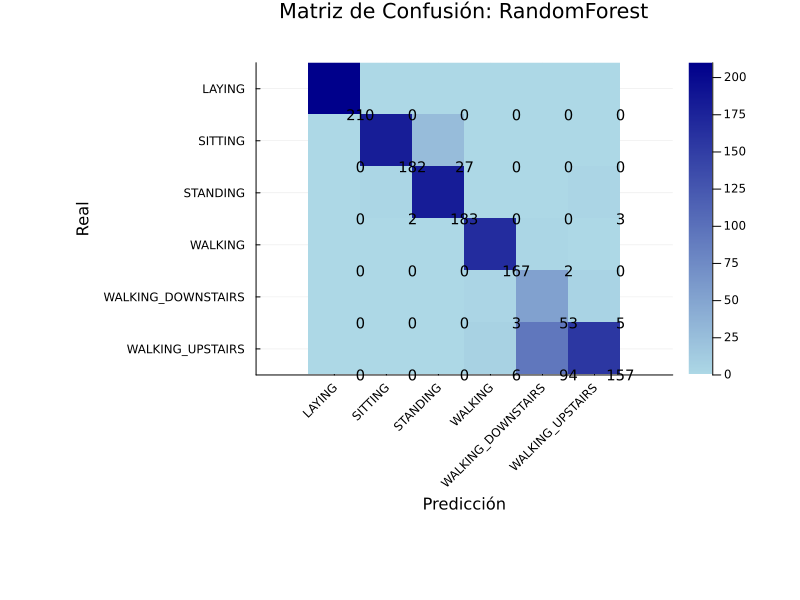

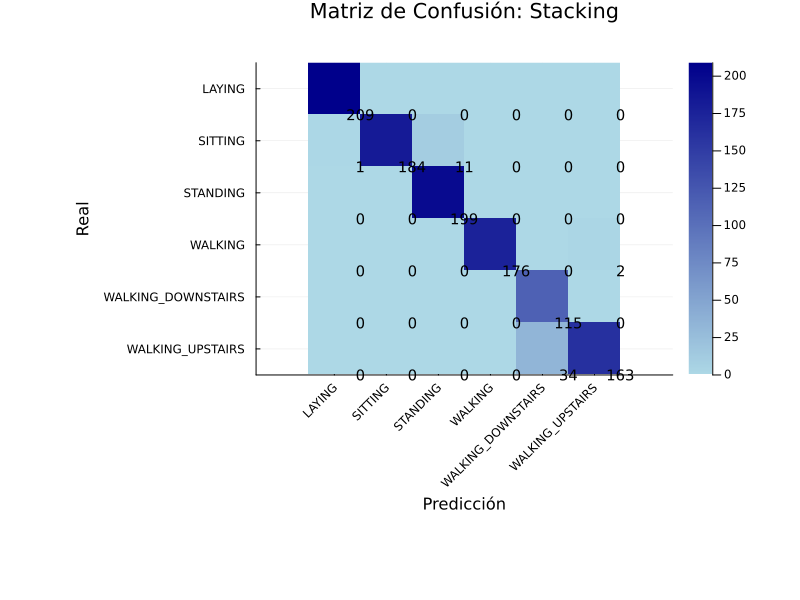

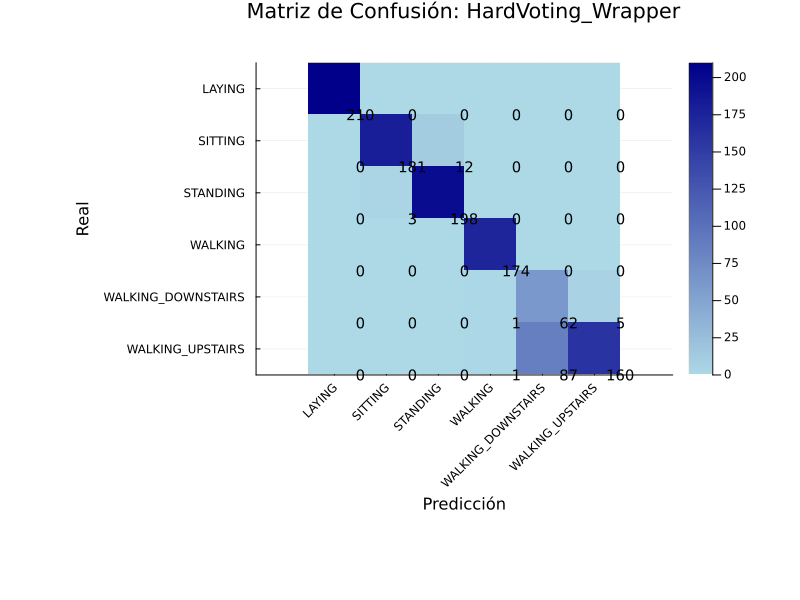

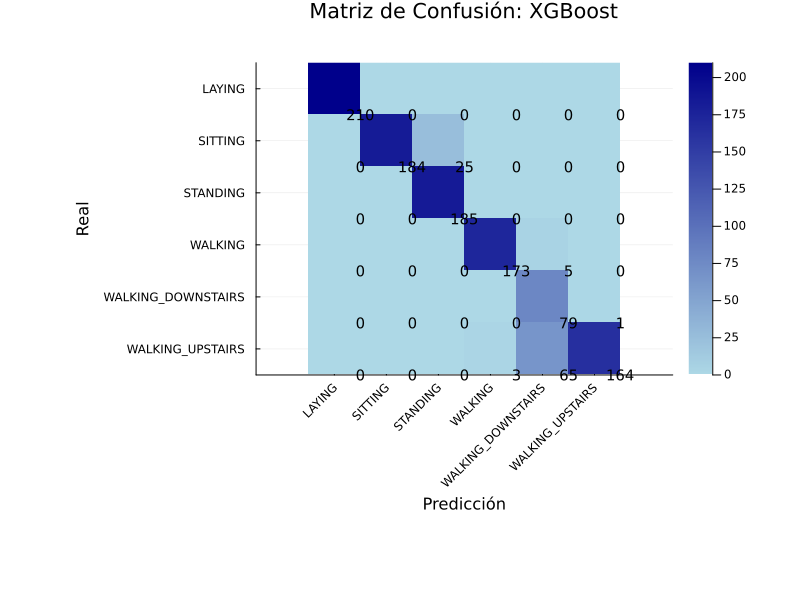

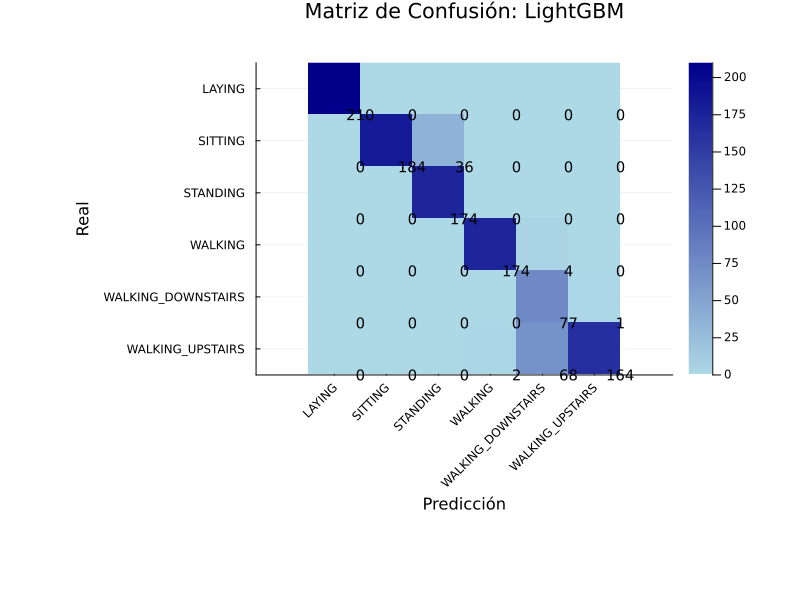

In [12]:
show_cm(dic_matrices_ensembles_finales)

# Significación de las Variables

In [13]:
# Definición de los modelos 
rf_model = RandomForestClassifier(n_trees=500, max_depth=10, rng=Random.MersenneTwister(SEED))
xgb_model = XGBoostClassifier(objective = "multi:softprob", seed=SEED)

# Random Forest
println("Entrenando Random Forest...")
mach_rf = machine(rf_model, X_trainval, y_trainval)
fit!(mach_rf, verbosity=0)

# XGBoost
println("Entrenando XGBoost...")
mach_xgb = machine(xgb_model, X_trainval, y_trainval)
fit!(mach_xgb, verbosity=0)

Entrenando Random Forest...
Entrenando XGBoost...


trained Machine; caches model-specific representations of data
  model: XGBoostClassifier(test = 1, …)
  args: 
    1:	Source @092 ⏎ Table{AbstractVector{Continuous}}
    2:	Source @896 ⏎ AbstractVector{Multiclass{6}}


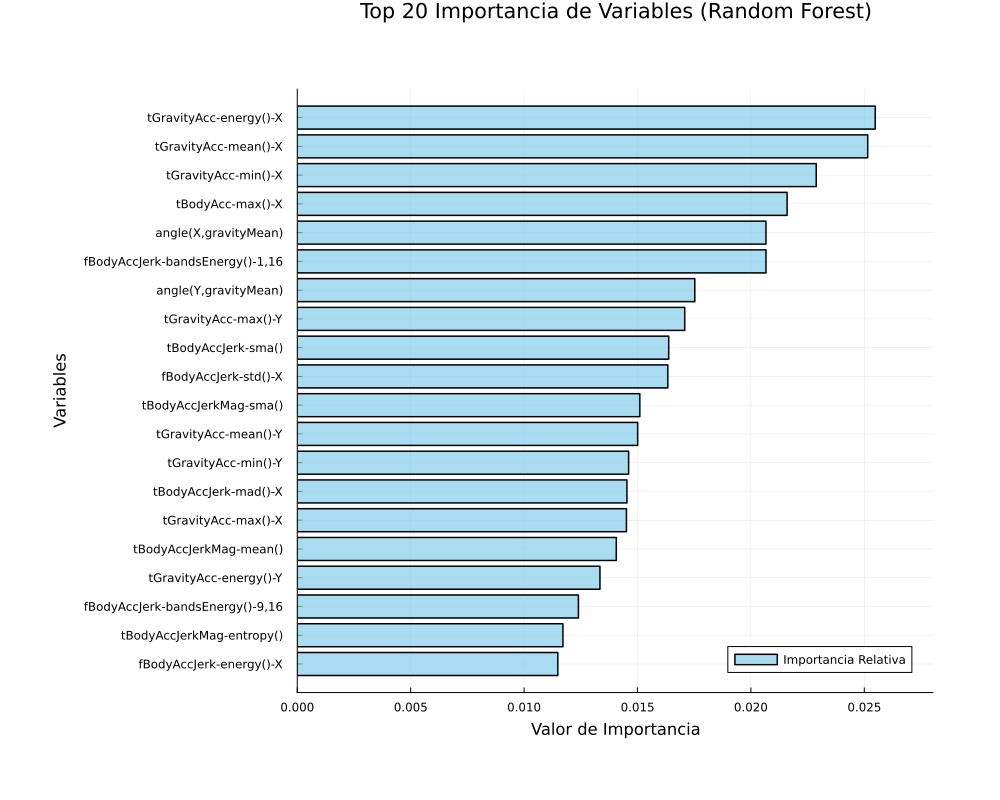

In [14]:
valores_importantes_rf = feature_importances(mach_rf)
rf_importances = DataFrame(
    feature = [p.first for p in valores_importantes_rf],
    importance = [p.second for p in valores_importantes_rf]
)

rf_importances_20 = reverse(rf_importances[1:20, :]) # Las 20 mejores

bar(
    rf_importances_20.importance,               
    orientation = :horizontal,            
    yticks = (1:20, String.(rf_importances_20.feature)), 
    title = "Top 20 Importancia de Variables (Random Forest)",
    xlabel = "Valor de Importancia",
    ylabel = "Variables",
    label = "Importancia Relativa",
    color = :skyblue,
    fillalpha = 0.7,
    linewidth = 1.5,
    xlims = (0, maximum(rf_importances_20.importance) * 1.1), 
    size = (1000, 800),                   
    margin = 15Plots.mm,                  
    legend = :bottomright
)

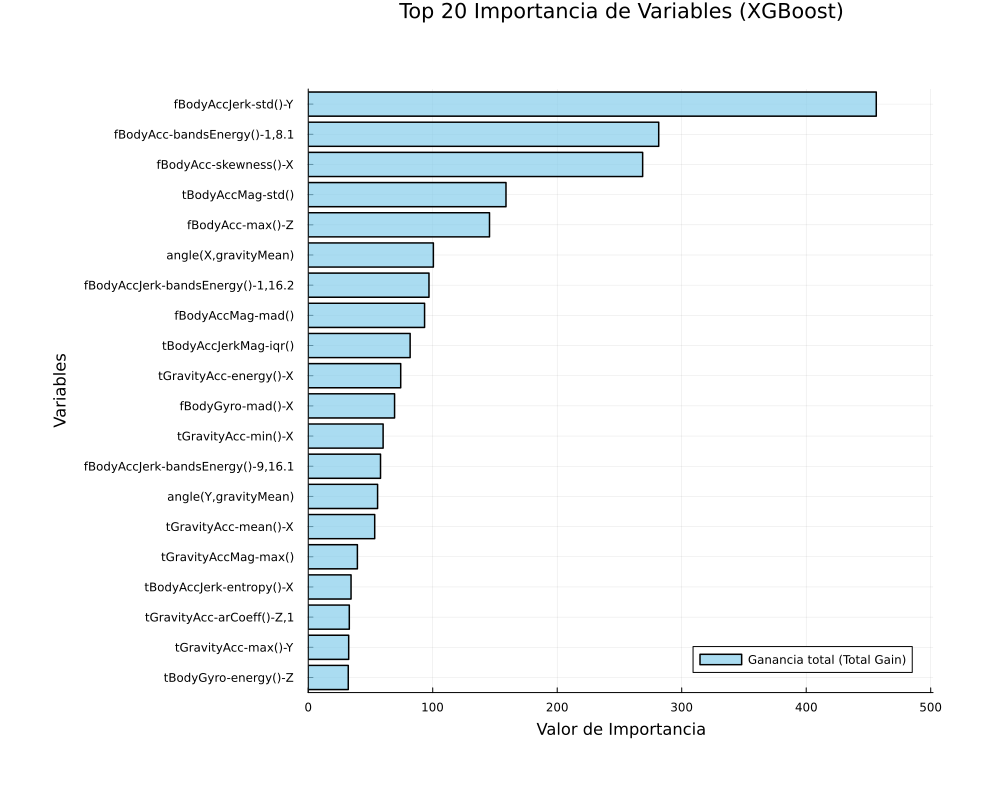

In [15]:
valores_importantes_xgboost = feature_importances(mach_xgb)
xgb_importances = DataFrame(
    feature = [p.first for p in valores_importantes_xgboost],
    importance = [p.second for p in valores_importantes_xgboost]
)

xgb_importances_20 = reverse(xgb_importances[1:20, :]) # Las 20 mejores

variables = String.(xgb_importances_20.feature)
importancia = xgb_importances_20.importance

bar(
    xgb_importances_20.importance,               
    orientation = :horizontal,            
    ylimits = (0.5, 20.5),
    yticks = (1:20, String.(xgb_importances_20.feature)),
    title = "Top 20 Importancia de Variables (XGBoost)", 
    xlabel = "Valor de Importancia",
    ylabel = "Variables",
    label = "Ganancia total (Total Gain)",
    color = :skyblue,
    fillalpha = 0.7,
    linewidth = 1.5,
    xlims = (0, maximum(xgb_importances_20.importance) * 1.1), 
    size = (1000, 800),                  
    margin = 15Plots.mm,                  
    legend = :bottomright
)

# Test Estadístico
## Validación de la Consistencia de los Folds (Datos Pareados)
Antes de realizar cualquier contraste de hipótesis, es bueno demostrar que las métricas obtenidas provienen de **muestras pareadas**. 
Dado que utilizamos una validación cruzada *Subject-wise* (por individuos), garantizamos la comparabilidad estadística fijando la semilla aleatoria (`SEED=104`). Esto asegura que:
1. El **Fold $i$** siempre contiene exactamente al mismo conjunto de sujetos de validación para todos los modelos.
2. Las diferencias de rendimiento se deben a la capacidad del modelo y no a variaciones en los datos de test.

In [16]:
# Reconstruimos los folds con la semilla original para ver quién está en el Fold 1
test_folds = subject_folds(df_trainval, k=5, seed=104)
subjects_fold_1 = unique(df_trainval[test_folds[1][2], :subject])

println("Sujetos en el Validation Set del Fold 1 (Semilla 104):")
println(sort(subjects_fold_1))

# Construcción de la Matriz de Resultados Pareados
model_names = sort(collect(keys(mejores_modelos))) # Orden alfabético para consistencia
resultados_por_fold = Dict{String, Vector{Float64}}()

println("--- Extracción de métricas por Fold (Balanced Accuracy) ---")

for nombre in model_names
    # Buscamos la fila correspondiente en el CSV de resultados
    row = nothing
    
    # Identificamos origen según familia
    if occursin("Bagging", nombre) || occursin("AdaBoost", nombre) || occursin("EvoTree", nombre)
        df_source = CSV.read("resultados_modelos_ensemble.csv", DataFrame)
    else
        df_source = CSV.read("resultados_modelos_basicos.csv", DataFrame)
    end
    
    # Extraemos la config del pipeline guardado en mejores_modelos[nombre]
    target_acc = mejores_modelos[nombre].clf isa Any ? nothing : nothing 

    # Como 'mejores_modelos' tiene claves custom ("SVM (Best)"), mapeamos a nombres del CSV
    csv_model_name = ""
    if occursin("SVM", nombre) csv_model_name = "SVM" 
    elseif occursin("KNN", nombre) csv_model_name = "KNN"
    elseif occursin("MLP", nombre) csv_model_name = "NeuralNetwork" 
    elseif occursin("Bagging", nombre) csv_model_name = "Bagging"
    elseif occursin("AdaBoost", nombre) csv_model_name = "AdaBoost"
    elseif occursin("EvoTree", nombre) csv_model_name = "EvoTree"
    end
    
    # Filtramos y ordenamos para coger el mejor
    subset = filter(row -> occursin(csv_model_name, string(row.Model)), df_source)
    sort!(subset, :B_Accuracy_mean, rev=true)
    
    if nrow(subset) > 0
        best_row = subset[1, :]
        # Parseamos el string a Vector
        str_vec = string(best_row.B_accuracy_list)
        if str_vec == "missing" || str_vec == ""
             error("No se encontraron datos por fold para $nombre. Verifica run_models.")
        end
        vals = parse.(Float64, split(str_vec, ";"))
        resultados_por_fold[nombre] = vals
    else
        warn("No se encontraron datos para $nombre")
    end
end

# Creamos DataFrame para visualización
df_folds_comparison = DataFrame(fold = 1:5)
for name in model_names
    df_folds_comparison[!, Symbol(name)] = resultados_por_fold[name]
end

println("Tabla de Balanced Accuracy por Fold (Datos Pareados):")
pretty_table(df_folds_comparison)

Sujetos en el Validation Set del Fold 1 (Semilla 104):
[1, 4, 8, 15, 23, 29]
--- Extracción de métricas por Fold (Balanced Accuracy) ---
Tabla de Balanced Accuracy por Fold (Datos Pareados):
┌───────┬─────────────────┬────────────────┬────────────────┬────────────┬────────────┬────────────┐
│  fold │ AdaBoost (Best) │ Bagging (Best) │ EvoTree (Best) │ KNN (Best) │ MLP (Best) │ SVM (Best) │
│ Int64 │         Float64 │        Float64 │        Float64 │    Float64 │    Float64 │    Float64 │
├───────┼─────────────────┼────────────────┼────────────────┼────────────┼────────────┼────────────┤
│     1 │         0.69365 │        0.89915 │        0.94231 │    0.96633 │    0.89364 │     0.9595 │
│     2 │         0.73162 │        0.88716 │        0.88292 │    0.94923 │    0.91274 │    0.91366 │
│     3 │         0.72019 │        0.88855 │        0.91685 │    0.95082 │    0.90341 │    0.93447 │
│     4 │         0.77213 │        0.92028 │        0.91872 │    0.94778 │    0.91095 │    0.92812 │
│

## Comprobación de Distribución
Se ha inspeccionado visualmente la distribución del rendimiento (Balanced Accuracy) en los 5 folds mediante diagramas de caja.

**Interpretación de la Gráfica:**
* **Asimetría:** Se observa claramente que la distribución de los resultados no es simétrica.
* **Heterogeneidad de Varianza:** Existe una gran disparidad en la dispersión de los resultados. Mientras que **EvoTree** y **SVM** muestran una varianza extremadamente baja (cajas muy comprimidas), **AdaBoost** presenta una dispersión mucho mayor entre folds.

La falta de simetría en varios modelos y las diferencias de varianza invalidan realizar tests paramétricos (como ANOVA). Por todo esto, usaremos el **Test de Friedman**, una alternativa no paramétrica que trabaja sobre rangos (rankings) en lugar de valores brutos, siendo robusto ante estas irregularidades distribucionales.

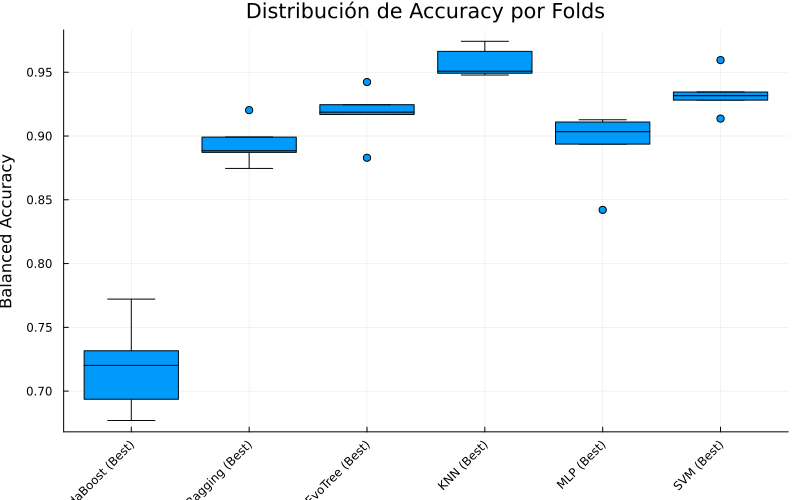

In [17]:
# Convertimos el DataFrame a una Matriz numérica pura (5 filas x 6 modelos)
matriz_resultados = Matrix(DataFrames.select(df_folds_comparison, Not(:fold)))
nombres_modelos = names(df_folds_comparison, Not(:fold))

# Aplanamos la matriz para tener un vector largo de 30 valores (5 folds * 6 modelos)
y_vals = vec(matriz_resultados)

# Creamos el vector de etiquetas repetidas
group_labels = repeat(nombres_modelos, inner=5)

# Visualización 
p_box = boxplot(
    group_labels, 
    y_vals, 
    title = "Distribución de Accuracy por Folds",
    ylabel = "Balanced Accuracy",
    xrotation = 45,
    legend = false,
    outliers = true,
    size = (800, 500)
)
display(p_box)

## Test de Friedman y Análisis Post-Hoc
Tras verificar la no-normalidad de los datos, procedemos a realizar la validación estadística en dos etapas:

1.  **Test de Friedman:**
    * **Objetivo:** Determinar si existen diferencias estadísticamente significativas globales entre los $k$ modelos.
    * **Hipótesis Nula ($H_0$):** Todos los algoritmos tienen un rendimiento equivalente (sus rankings medios son iguales).
    * **Funcionamiento:** Calcula el ranking de cada modelo en cada fold y compara si el ranking promedio difiere de lo esperado por azar.

2.  **Test de Wilcoxon Signed-Rank (Post-Hoc):**
    * **Objetivo:** Si el test de Friedman rechaza $H_0$, comparamos los modelos par a par para identificar qué diferencias específicas son significativas.
    * **Corrección:** Se reportan los p-valores directos.

In [24]:
println("=== 1. Test de Friedman ===")

# Validar que existe la matriz
if !@isdefined(matriz_resultados)
    error("No se encuentra 'matriz_resultados'. Ejecuta la celda del Boxplot primero.")
end

# Ejecutamos nuestra función
stat_friedman, p_val_friedman, ranks_matrix = my_friedman_test(matriz_resultados)

println("Estadístico Q: $(@sprintf("%.4f", stat_friedman))")
println("P-Value:       $(@sprintf("%.5f", p_val_friedman))")

if p_val_friedman < 0.05
    println("\n CONCLUSIÓN: Hay diferencias significativas (p < 0.05).")
    println("    -> Se rechaza la hipótesis nula de que todos los modelos son iguales.")
    println("    -> Procediendo al análisis Post-Hoc (Wilcoxon)...\n")
    
    println("=== 2. Test Post-Hoc: Wilcoxon Signed-Rank (Par a Par) ===")
    
    # Preparar tabla
    @printf("%-20s vs %-20s | %-10s | %-12s | %s\n", "Modelo A", "Modelo B", "P-Value", "Ganador", "¿Signif.?")
    println("-"^95)
    
    model_indices = 1:length(nombres_modelos)
    
    for (i, j) in combinations(model_indices, 2)
        name_a = nombres_modelos[i]
        name_b = nombres_modelos[j]
        
        # Datos pareados originales
        data_a = matriz_resultados[:, i]
        data_b = matriz_resultados[:, j]
        
        # Test Wilcoxon
        wt = SignedRankTest(data_a, data_b)
        p_val = pvalue(wt)
        
        # Ganador basado en la mediana de accuracy
        med_a = median(data_a)
        med_b = median(data_b)
        ganador = med_a > med_b ? "A ($name_a)" : (med_b > med_a ? "B ($name_b)" : "Empate")
        
        significativo = p_val < 0.05 ? "*" : ""
        
        @printf("%-20s vs %-20s | %.5f    | %-12s | %s\n", 
                name_a, name_b, p_val, ganador, significativo)
    end
    
    println("\nLeyenda: (*) Diferencia significativa (p < 0.05).")

else
    println("\n CONCLUSIÓN: No hay diferencias significativas (p >= 0.05).")
    println("    -> El rendimiento de los modelos es estadísticamente equivalente.")
end

=== 1. Test de Friedman ===
Estadístico Q: 22.6000
P-Value:       0.00040

 CONCLUSIÓN: Hay diferencias significativas (p < 0.05).
    -> Se rechaza la hipótesis nula de que todos los modelos son iguales.
    -> Procediendo al análisis Post-Hoc (Wilcoxon)...

=== 2. Test Post-Hoc: Wilcoxon Signed-Rank (Par a Par) ===
Modelo A             vs Modelo B             | P-Value    | Ganador      | ¿Signif.?
-----------------------------------------------------------------------------------------------
AdaBoost (Best)      vs Bagging (Best)       | 0.06250    | B (Bagging (Best)) | 
AdaBoost (Best)      vs EvoTree (Best)       | 0.06250    | B (EvoTree (Best)) | 
AdaBoost (Best)      vs KNN (Best)           | 0.06250    | B (KNN (Best)) | 
AdaBoost (Best)      vs MLP (Best)           | 0.06250    | B (MLP (Best)) | 
AdaBoost (Best)      vs SVM (Best)           | 0.06250    | B (SVM (Best)) | 
Bagging (Best)       vs EvoTree (Best)       | 0.31250    | B (EvoTree (Best)) | 
Bagging (Best)      

## Interpretación

**Resultados del Test de Friedman:**
El test de Friedman arrojó un **p-valor de 0.0004**, muy inferior al nivel de significancia $\alpha=0.05$. Esto confirma que **existen diferencias significativas** en el rendimiento de los distintos algoritmos.

**Análisis Post-Hoc (Wilcoxon Signed-Rank):**
Al observar las comparaciones par a par, encontramos un fenómeno derivado del tamaño muestral de la validación cruzada ($k=5$ folds).
* El p-valor mínimo posible para $N=5$ en un test de dos colas es **0.0625** (que ocurre cuando un modelo supera al otro en todos los folds: 5-0).
* Aunque este valor es estrictamente superior a 0.05, representa la **máxima evidencia de superioridad posible**.

**Conclusiones Específicas:**
1.  **El Mejor Modelo (KNN):** El clasificador **KNN (Best)** ha demostrado ser el algoritmo superior de forma consistente. En las comparaciones par a par, obtiene un p-valor de 0.0625 contra **todos** los demás modelos (SVM, MLP, EvoTree, Bagging y AdaBoost). Esto implica que KNN superó a sus competidores en el 100% de los folds de validación.
2.  **El Segundo Mejor (SVM):** El modelo SVM superó consistentemente a AdaBoost, Bagging, EvoTree y MLP (p=0.0625), perdiendo únicamente contra KNN.
3.  **Rendimiento Inferior (AdaBoost):** Por el contrario, AdaBoost perdió contra todos los demás clasificadores (p=0.0625 en todas las comparaciones donde participó como perdedor).

**Decisión Final:**
Basándonos en la consistencia de los resultados (victoria en 5/5 folds contra todos los rivales), seleccionamos **KNN** como el modelo final para la evaluación sobre el conjunto de test reservado, respaldado por la evidencia estadística disponible.